# Import statements

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

from portfolio_optimizer.data_loader import (
    download_prices,
    compute_returns,
    compute_covariance_matrix
)

from portfolio_optimizer.optimization_lp import (
    baseline_lp,
    risk_constrained_lp
)

from portfolio_optimizer.optimization_milp import (
    milp_rebalancing
)

from portfolio_optimizer.optimization_qp import (
    sharpe_optimization,
    portfolio_risk
)

from portfolio_optimizer.plots import plot_weights

# Pull Data

In [2]:
tickers = ["SPY", "QQQ", "MAIN", "O", "SCHD", "VEA", "VWO", "BND"]

prices = download_prices(
    tickers,
    "2024-03-11",
    "2026-03-11"
)

[*********************100%***********************]  8 of 8 completed


# Models

## Baseline LP

  Asset  Weight
0   SPY    0.00
1   QQQ    0.00
2  MAIN    0.00
3     O    0.35
4  SCHD    0.00
5   VEA    0.30
6   VWO    0.00
7   BND    0.35
Expected Portfolio Return: 0.1664


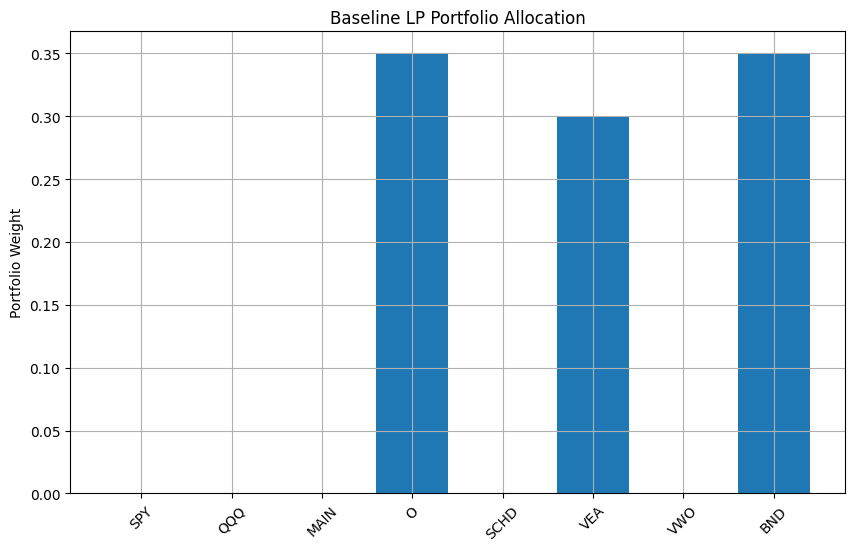

In [3]:

returns, mean_returns, risk = compute_returns(prices)

weights, portfolio_return = baseline_lp(mean_returns)

weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": weights
})

weights_df["Weight"] = weights_df["Weight"].round(4)

print(weights_df)

print(f"Expected Portfolio Return: {portfolio_return:.4f}")

plot_weights(
    weights,
    tickers,
    "Baseline LP Portfolio Allocation"
)

## Risk Constrained LP

  Asset  Weight
0   SPY    0.00
1   QQQ    0.00
2  MAIN    0.00
3     O    0.35
4  SCHD    0.00
5   VEA    0.30
6   VWO    0.00
7   BND    0.35


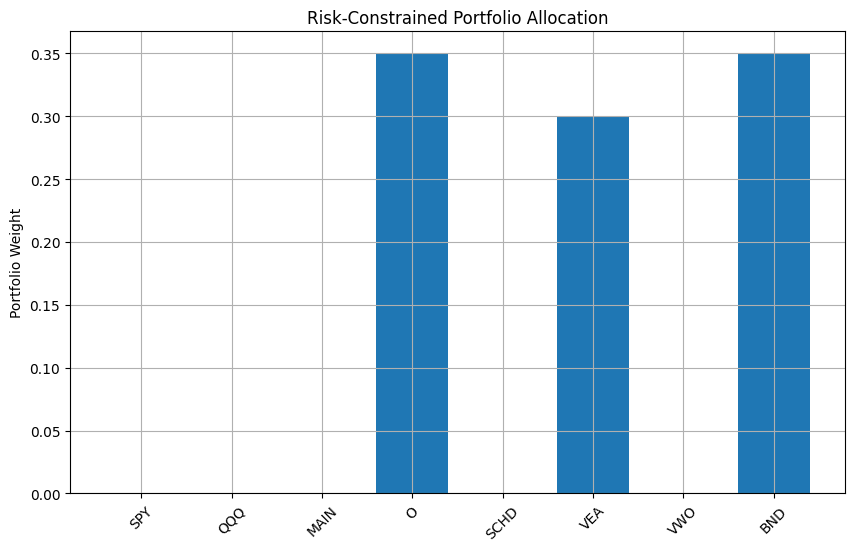

In [4]:

risk_weights, risk_return, risk_value = risk_constrained_lp(
    mean_returns,
    risk
)

risk_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": risk_weights
})

risk_df["Weight"] = risk_df["Weight"].round(4)

print(risk_df)

plot_weights(
    risk_weights,
    tickers,
    "Risk-Constrained Portfolio Allocation"
)

## MILP

In [5]:

current_weights = pd.Series(
    np.ones(len(tickers)) / len(tickers),
    index=tickers
)

(
    milp_weights,
    buys,
    sells,
    traded,
    milp_return
) = milp_rebalancing(
    mean_returns,
    current_weights
)

milp_df = pd.DataFrame({
    "Asset": tickers,
    "NewWeight": milp_weights,
    "Buy": buys,
    "Sell": sells,
    "Traded": traded
})

milp_df.round(4)

,Asset,NewWeight,Buy,Sell,Traded
0,SPY,0.000,0.000,0.125,1.0
1,QQQ,0.125,0.000,0.000,0.0
2,MAIN,0.125,0.000,0.000,0.0
3,O,0.350,0.225,0.000,1.0
4,SCHD,0.000,0.000,0.125,1.0
5,VEA,0.125,0.000,0.000,0.0
6,VWO,0.125,0.000,0.000,0.0
7,BND,0.150,0.025,0.000,1.0


## QP

Expected Return: 0.1516
Portfolio Risk: 0.1290
Sharpe Ratio: 1.0200


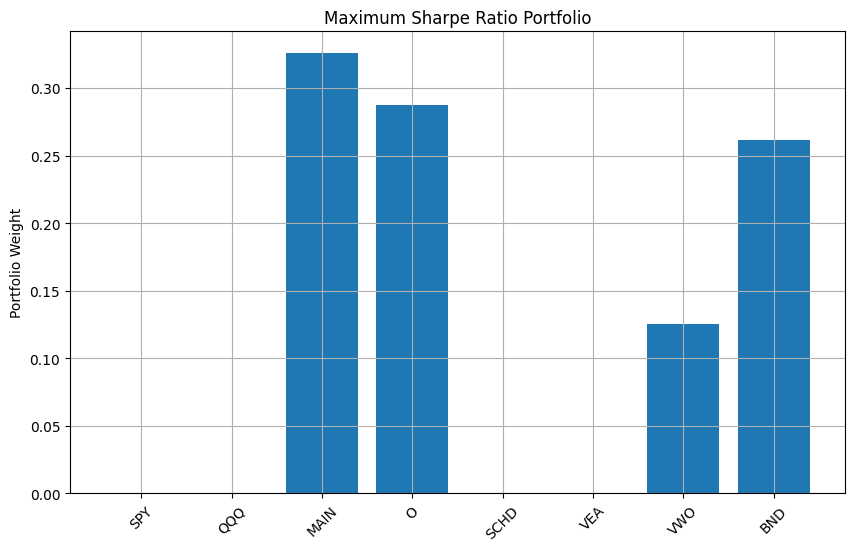

In [6]:
cov_matrix = compute_covariance_matrix(
    returns
)

(
    sharpe_weights,
    sharpe_return,
    sharpe_risk,
    sharpe_ratio
) = sharpe_optimization(
    mean_returns,
    cov_matrix
)

sharpe_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": sharpe_weights
})

sharpe_df["Weight"] = sharpe_df["Weight"].round(4)

sharpe_df

print(f"Expected Return: {sharpe_return:.4f}")
print(f"Portfolio Risk: {sharpe_risk:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

plot_weights(
    sharpe_weights,
    tickers,
    "Maximum Sharpe Ratio Portfolio"
)